# 01 — Análise Exploratória de Dados

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura não comunica nada.

In [31]:
from pathlib import Path

# Verifica onde o notebook está rodando
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..")
else:
    PROJECT_ROOT = Path(".")

print("Caminho raíz resolvido:", PROJECT_ROOT.resolve())
list(PROJECT_ROOT.iterdir())


Caminho raíz resolvido: /home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2


[PosixPath('results'),
 PosixPath('.github'),
 PosixPath('LICENSE'),
 PosixPath('ESTRUTURA.md'),
 PosixPath('data'),
 PosixPath('.gitignore'),
 PosixPath('.git'),
 PosixPath('requirements.txt'),
 PosixPath('src'),
 PosixPath('implementacao_notebooks.md'),
 PosixPath('submissao'),
 PosixPath('README.md'),
 PosixPath('docs'),
 PosixPath('CHECKLIST.md'),
 PosixPath('.venv'),
 PosixPath('.tool-versions'),
 PosixPath('notebooks')]

In [32]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..")
else:
    PROJECT_ROOT = Path(".")

RAW_APP = PROJECT_ROOT / "data" / "raw" / "application_record.csv"
RAW_CREDIT = PROJECT_ROOT / "data" / "raw" / "credit_record.csv"
PROCESSED = PROJECT_ROOT / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [33]:
df_app = pd.read_csv(RAW_APP)
df_app.head()   

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [34]:
df_credit = pd.read_csv(RAW_CREDIT)
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [35]:
# Carregando os datasets
df_app = pd.read_csv(RAW_APP)
df_credit = pd.read_csv(RAW_CREDIT)

# Criando a variável Target: 
# Vamos considerar "Mau pagador" (1) se o cliente atrasou mais de 60 dias (status 2, 3, 4, 5) em algum mês.
bad_status = ['2', '3', '4', '5']
df_credit['is_bad'] = df_credit['STATUS'].isin(bad_status).astype(int)

# Agrupando por ID: se o cliente foi 'is_bad' em qualquer mês, ele recebe target 1
target_df = df_credit.groupby('ID')['is_bad'].max().reset_index()
target_df.rename(columns={'is_bad': TARGET}, inplace=True)

# Mesclando com os dados de aplicação (inner join para manter apenas quem tem histórico de crédito)
df = df_app.merge(target_df, on='ID', how='inner')

display(df.head())
df.info()
df.describe().T

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3153.0,-1552.0,-408.0,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.0,2.0,3.0,20.0


## 2. Distribuição das variáveis

**Interpretação:** _preencher._

In [36]:
# histogramas / boxplots

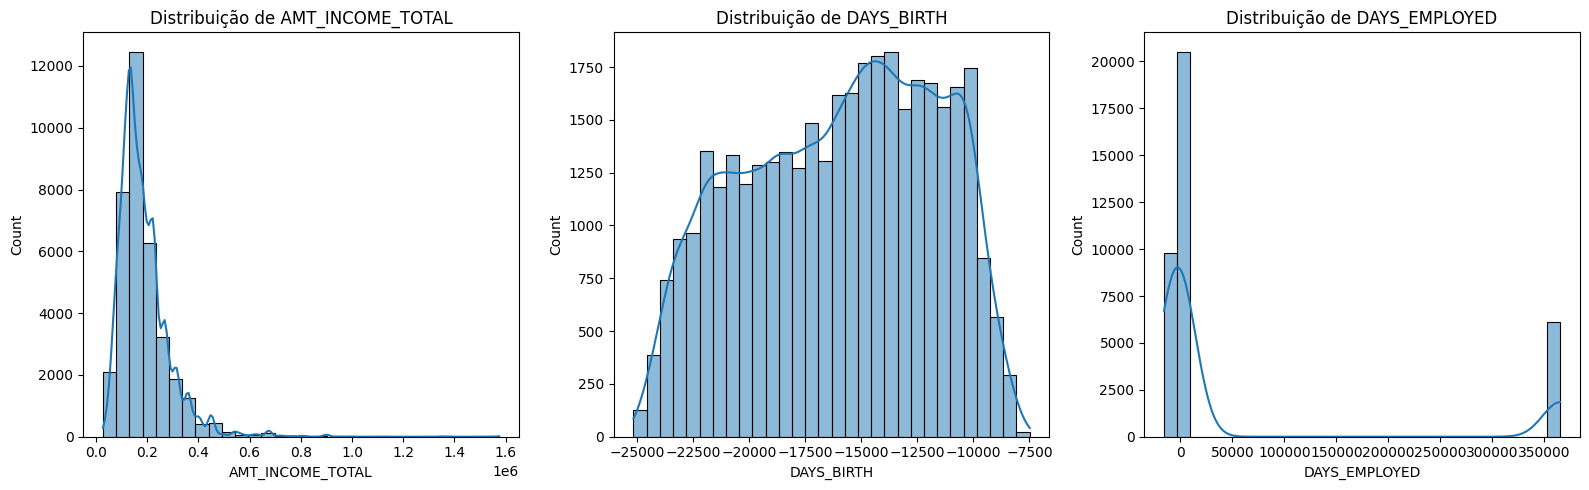

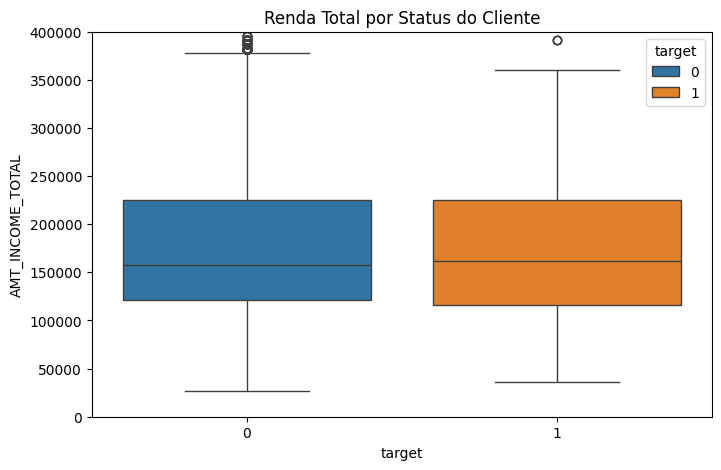

In [37]:
# Distribuição das principais variáveis contínuas
numeric_cols = ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

# Boxplot para visualizar a renda vs. ser ou não mau pagador
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET, y='AMT_INCOME_TOTAL', hue=TARGET)
plt.title('Renda Total por Status do Cliente')
plt.ylim(0, 400000) # Limitando o eixo Y para enxergar o box ignorando outliers extremos
plt.show()

A renda é bastante assimétrica (concentrada em valores mais baixos com longa cauda à direita). Os dias de nascimento são negativos (representam dias passados desde o nascimento). DAYS_EMPLOYED possui um pico enorme em valores positivos, o que indica uma anomalia que precisará ser tratada.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [38]:
# heatmap de correlação

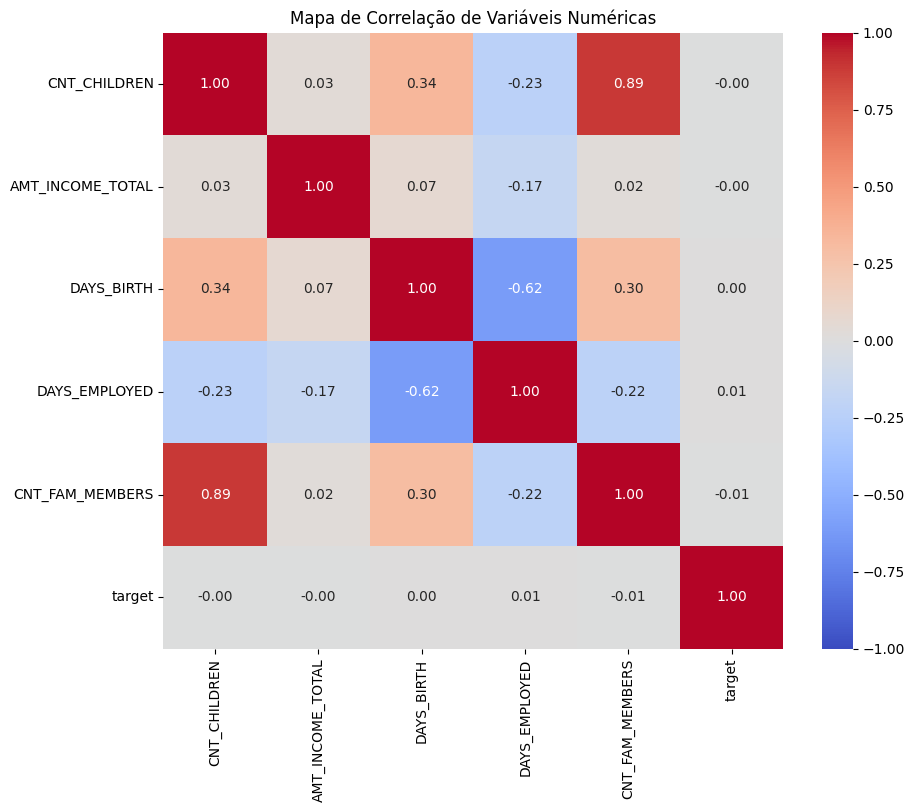

In [39]:
# Filtrando apenas numéricas e removendo IDs/Flags de pouco valor para correlação linear
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])
cols_to_drop = ['ID', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
numeric_df = numeric_df.drop(columns=[c for c in cols_to_drop if c in numeric_df.columns])

plt.figure(figsize=(10, 8))
corr = numeric_df.corr()

# Plot do Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Correlação de Variáveis Numéricas')
plt.show()

`CNT_CHILDREN` (número de filhos) e `CNT_FAM_MEMBERS` (tamanho da família) possuem uma altíssima correlação positiva, indicando redundância. As variáveis demográficas possuem pouca correlação direta forte com o `target`, sugerindo relações não-lineares.

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [40]:
# detecção de outliers

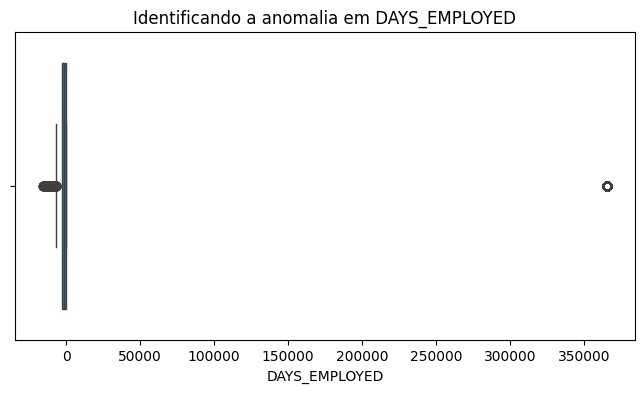

Valor do Outlier: 365243 dias (+1000 anos de emprego)
Clientes com esse valor: 6135 (16.8%)
Status ocupacional desses clientes:
NAME_INCOME_TYPE
Pensioner    6135
Name: count, dtype: int64


In [41]:
# Verificando a anomalia em DAYS_EMPLOYED
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['DAYS_EMPLOYED'])
plt.title('Identificando a anomalia em DAYS_EMPLOYED')
plt.show()

anomalia_val = df['DAYS_EMPLOYED'].max()
qtd_anomalia = len(df[df['DAYS_EMPLOYED'] == anomalia_val])
print(f"Valor do Outlier: {anomalia_val} dias (+1000 anos de emprego)")
print(f"Clientes com esse valor: {qtd_anomalia} ({qtd_anomalia/len(df)*100:.1f}%)")
print(f"Status ocupacional desses clientes:\n{df[df['DAYS_EMPLOYED'] == anomalia_val]['NAME_INCOME_TYPE'].value_counts()}")


O valor `365243` dias trabalhados é um placeholder (provavelmente para desempregados/pensionistas) e corresponde a 1000 anos. Isso deverá ser transformado na etapa de pré-processamento (por exemplo, definido como 0 ou em uma categoria separada).

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [42]:
df[TARGET].value_counts(normalize=True)

target
0    0.983103
1    0.016897
Name: proportion, dtype: float64

Proporção do Target (%):
target
0    98.31
1     1.69
Name: proportion, dtype: float64


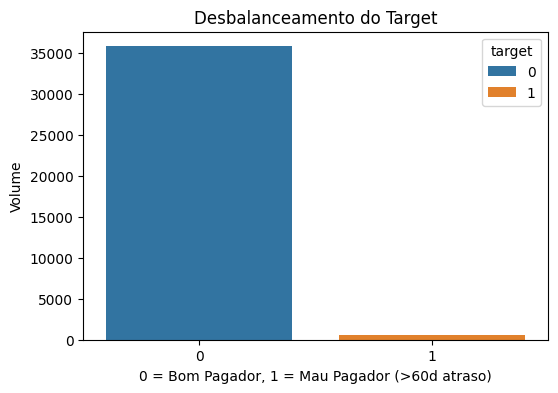

In [43]:
target_pct = df[TARGET].value_counts(normalize=True) * 100
print("Proporção do Target (%):")
print(target_pct.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, hue=TARGET)
plt.title('Desbalanceamento do Target')
plt.ylabel('Volume')
plt.xlabel('0 = Bom Pagador, 1 = Mau Pagador (>60d atraso)')
plt.show()

O dataset é **altamente desbalanceado**, com quase 98% de bons pagadores e ~2% de maus pagadores. Isso indica que precisaremos utilizar métricas como F1-Score, ROC-AUC e técnicas de balanceamento (SMOTE, Class Weights) na etapa de modelagem, pois a Acurácia pura será ilusória.

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._